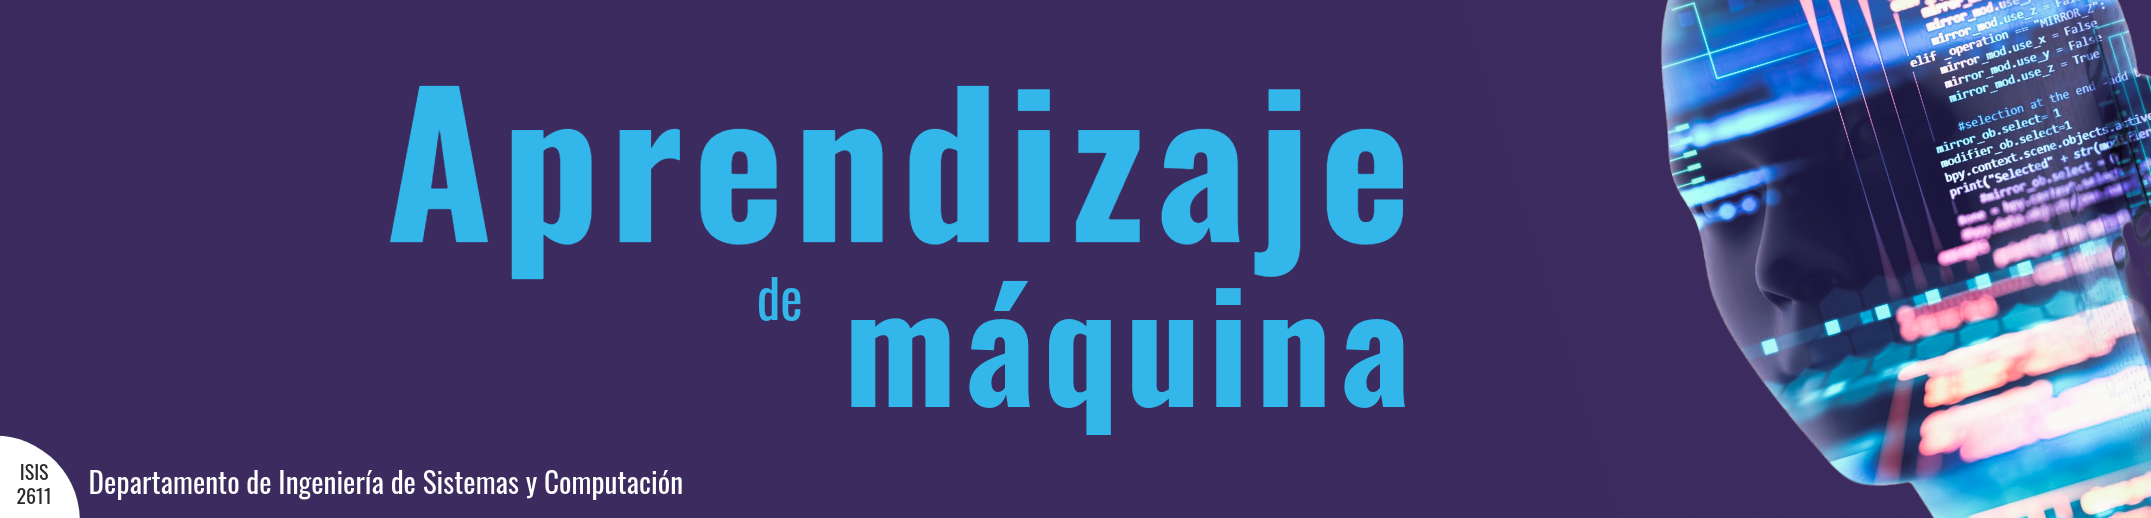

# Naive Bayes como Clasificador Generativo

Hasta ahora, los clasificadores empleados se han centrado en el aprendizaje de fronteras de decisión para segmentar el espacio de características según las etiquetas de entrenamiento. Estos se denominan **Modelos Discriminativos**, ya que su objetivo principal es modelar directamente la probabilidad condicional $\mathbb{P}(Y|X)$ para distinguir entre clases. En contraste, los **Modelos Generativos** adoptan un enfoque basado en la estructura subyacente de los datos. Mediante el uso de la regla de Bayes, $\mathbb{P}(X, Y) = \mathbb{P}(X | Y)\mathbb{P}(Y) = \mathbb{P}(Y|X)\mathbb{P}(X)$, estos modelos aprenden la distribución conjunta de las variables $\mathbb{P}(X, Y)$. Al comprender cómo se distribuyen los datos para cada clase, no solo pueden clasificar, sino también generar nuevas muestras sintéticas que sigan dicha distribución.

En esta ocasión el modelo generativo con el que se va a trabajar es **Naive Bayes**, el cual recibe su nombre por la suposición que hace para aprender la distribución conjunta. El algoritmo asume que todas las características del conjunto de datos, denotadas por $X_i$, son condicionalmente independientes entre sí dado el valor de la clase $Y$. Esta simplificación permite descomponer la verosimilitud de la siguiente manera:

$$
\begin{align*}
\mathbb{P}(X | Y) &= \mathbb{P}(X_1, X_2, \cdots, X_n | Y)\\
                  &= \mathbb{P}(X_1 | Y, X_2, \cdots, X_n) \times \mathbb{P}(X_2 | Y, X_3, \cdots, X_n) \times \cdots \times \mathbb{P}(X_n | Y)\\
                  &= \mathbb{P}(X_1 | Y) \times \mathbb{P}(X_2 | Y) \times \cdots \times \mathbb{P}(X_n | Y)
\end{align*}
$$

De este modo, el modelo evita la complejidad de calcular las dependencias mutuas entre variables, facilitando el entrenamiento con grandes volúmenes de datos.

El conjunto de datos que se utilizará es MNIST (Modified National Institute of Standards and Technology), uno de los referentes clásicos en el campo de la visión por computador. Este dataset fue popularizado por Yann LeCun en su artículo de 1998, [*Gradient-Based Learning Applied to Document Recognition*](http://vision.stanford.edu/cs598_spring07/papers/Lecun98.pdf), donde se presentó una de las arquitecturas fundacionales de las Redes Neuronales Convolucionales (CNN). MNIST está compuesto por 70,000 imágenes en escala de grises, cada una con una resolución de 28 × 28 píxeles. Cada imagen representa un dígito manuscrito entre 0 y 9, y el conjunto se utiliza ampliamente para el entrenamiento y la evaluación de modelos de reconocimiento de patrones.

La estructura de este notebook se organiza en cuatro etapas principales: exploración del conjunto de datos, construcción del modelo, evaluación del desempeño y generación de datos, con base en la siguiente estructura:

1. Importación de librerías.
2. Carga de datos.
3. Exploración de datos.
4. Partición de datos.
5. Construcción y entrenamiento del modelo.
6. Evaluación del desempeño.
7. Generación de datos.
8. Ejercicios


## 1. Importación de librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

## 2. Carga de datos.

Los datos se descargan mediante la función `fetch_openml()`, pasando el identificador `mnist_784`. Este nombre indica que cada imagen del conjunto MNIST está representada por un vector de $784$ elementos ($28 \times 28$ píxeles). Además, configuramos `version=1` para asegurar el uso de la versión original y `as_frame=False` para trabajar directamente con estructuras de NumPy en lugar de DataFrames.


In [2]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
x, y = mnist["data"], mnist["target"]

## 3. Exploración del conjunto de datos


Una vez con los datos cargados, se procede a explorarlos con el fin de observar su estructura y distribución:

In [3]:
x.shape

(70000, 784)

Al inspeccionar el arreglo de los datos se confirma que este consta de $70,000$ imágenes, cada una con una longitud de $784$.

In [4]:
y.shape

(70000,)

En cuanto al arreglo de etiquetas se nota que tiene el mismo tamaño que el conjunto de datos, por lo que no se presentan problemas de completitud.

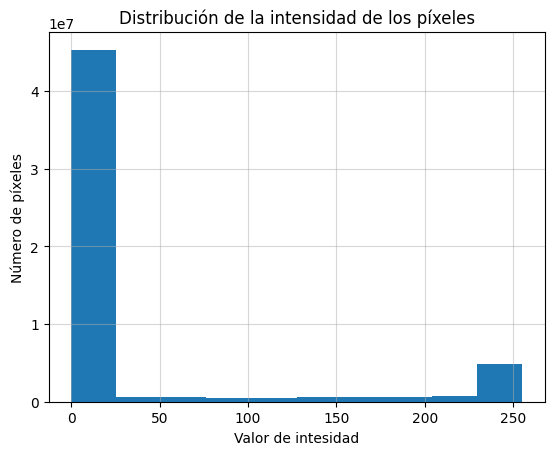

In [5]:
counts, bin_edges = np.histogram(x, bins=10)

fig, ax = plt.subplots()
ax.stairs(counts, bin_edges, fill=True)
ax.set(xlabel='Valor de intesidad', ylabel='Número de píxeles', title='Distribución de la intensidad de los píxeles')
ax.grid(alpha=0.5)
plt.show()


Como es habitual en el procesamiento de imágenes, los valores son enteros que oscilan entre $0$ y $255$. Esto confirma la validez de los datos y descarta anomalías en su representación.

En cuanto a la distribución de intensidades, se observa que la gran mayoría de los píxeles tienen un valor de $0$, lo cual es consistente con el color del fondo. Adicionalmente, también existe una cantidad significativa de píxeles con valores cercanos a 255, los cuales corresponden a los trazos de los dígitos.

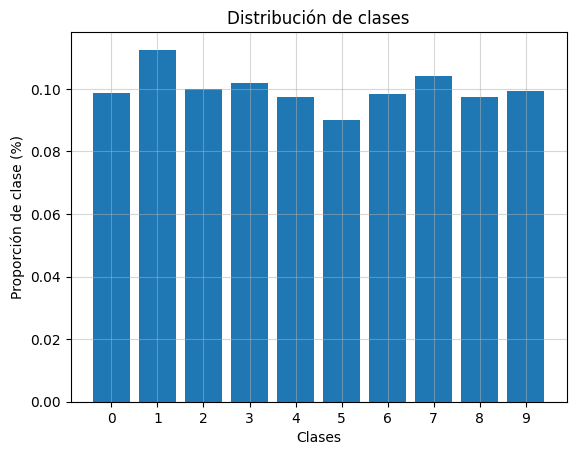

In [6]:
classes, counts = np.unique(y, return_counts=True)
fig, ax = plt.subplots()
ax.bar(classes, counts/len(x))
ax.set(title='Distribución de clases', xlabel='Clases', ylabel='Proporción de clase (%)')
ax.grid(alpha=0.5)
plt.show()

Al revisar la distribución de clases en el arreglo de etiquetas se encuentra que sus proporciones están balanceadas.

Finalmente, se realiza una exploración cualitativa del conjunto de datos. Para ello se toma una muestra aleatoria de las imágenes y se visualizan.


In [7]:
def show_img_sample(x, y):
  sample_indices = np.random.choice(len(x), 8)
  sample = x[sample_indices]
  sample_labels = y[sample_indices]

  fig, ax = plt.subplots(2, 4, layout='tight')

  img_idx = 0
  for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
      ax[i, j].imshow(sample[img_idx].reshape((28, 28)), cmap='gray')

      ax[i, j].set(title = f'Clase: {sample_labels[img_idx]}')
      ax[i, j].axis('off')

      img_idx += 1

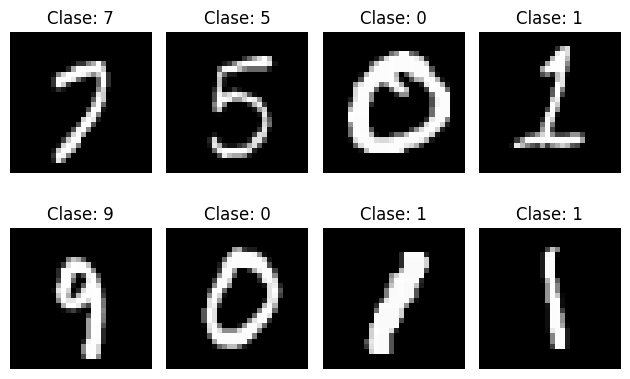

In [8]:
show_img_sample(x, y)

Las imágenes evidencian uno de los principales desafíos de este conjunto de datos: la alta variabilidad entre muestras de una misma clase, debido a diferencias en la escritura, grosor, inclinación y estilo de los dígitos manuscritos.

## 4. Partición de los datos



La partición de los datos se realiza de la misma forma en que se ha previamente, utilizando la función `train_test_split()`.

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y)

Se verifica que la distribución de las clases en los conjuntos de entrenamiento y evaluación son similares a las del conjunto completo.

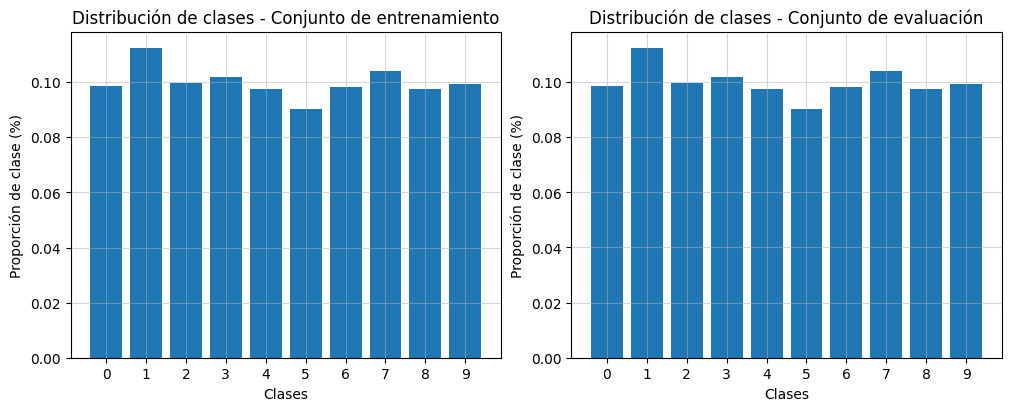

In [10]:
_, train_y_counts = np.unique(y_train, return_counts=True)
_, test_y_counts = np.unique(y_test, return_counts=True)

fig, ax = plt.subplots(1, 2, figsize=(10, 4), layout='constrained')

ax[0].bar(classes, train_y_counts/len(y_train))
ax[0].set(title='Distribución de clases - Conjunto de entrenamiento', xlabel='Clases', ylabel='Proporción de clase (%)')
ax[0].grid(alpha=0.5)

ax[1].bar(classes, test_y_counts/len(y_test))
ax[1].set(title='Distribución de clases - Conjunto de evaluación', xlabel='Clases', ylabel='Proporción de clase (%)')
ax[1].grid(alpha=0.5)

plt.show()

## 5. Construcción y entrenamiento del modelo.

Como se mencionó previamente, los modelos generativos operan mediante el aprendizaje de la distribución conjunta $\mathbb{P}(X,Y)$ a través de la regla de Bayes, fundamentándose en la descomposición $\mathbb{P}(X,Y) = \mathbb{P}(X|Y)\mathbb{P}(Y)$. En este contexto, las probabilidades $\mathbb{P}(X|Y)$ y $\mathbb{P}(Y)$ se estiman directamente a partir de los datos de entrenamiento. Para el análisis de imágenes en esta práctica, se ha seleccionado un clasificador Naive Bayes Gaussiano, el cual asume que las intensidades de los píxeles siguen una distribución normal. No obstante, dependiendo de la naturaleza de los datos, podrían emplearse variantes como Bernoulli, Multinomial o Poisson. Dado que cada imagen se representa como un vector de $784$ dimensiones, el modelo estima una media y una varianza por cada píxel y para cada clase. Así, $\mathbb{P}(X_i|Y=y)$ se obtiene de los parámetros estadísticos del entrenamiento, mientras que la probabilidad a priori $\mathbb{P}(Y=y)$ se calcula mediante la frecuencia relativa de cada etiqueta.

En este caso, dado que uno de los objetivos es utilizar el clasificador Naive Bayes como generador, no resulta conveniente aplicar preprocesamiento al conjunto de entrenamiento. El uso de técnicas como `StandardScaler()`) modificaría el rango original de los datos, lo que obligaría a realizar una transformación inversa durante la fase de generación. Si bien `StandardScaler()` es una transformación lineal que preserva la forma de la distribución, las verosimilitudes obtenidas serían equivalentes a las del modelo entrenado con los datos originales. En consecuencia, el preprocesamiento no aportaría una mejora significativa en el desempeño y, en cambio, introduciría una complejidad innecesaria en el flujo de trabajo.

Tras revisar la documentación de [`GaussianNB()`](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html#sklearn.naive_bayes.GaussianNB), se observa que el modelo cuenta únicamente con dos hiperparámetros: `priors`, para definir explícitamente la distribución $\mathbb{P}(Y)$, y `var_smoothing`, una constante añadida a las varianzas para evitar inestabilidades numéricas. Dada la naturaleza de estos hiperparámetros, no se considera necesario realizar una búsqueda sobre estos.

In [11]:
bayes = GaussianNB()
bayes.fit(x_train, y_train)

GaussianNB()

In [12]:
print(f'Dimensiones arreglo de medias: {bayes.theta_.shape}')
print(f'Dimensiones arreglo de varianzas: {bayes.var_.shape}')

Dimensiones arreglo de medias: (10, 784)
Dimensiones arreglo de varianzas: (10, 784)


La inspección de las dimensiones de los arreglos de medias y varianzas confirma que el modelo tiene la estructura esperada: un vector de medias y uno de varianzas para cada una de las clases con los valores correspondientes a cada pixel.


## 6. Evaluación del desempeño.

Tras estimar la distribución conjunta $\mathbb{P}(X,Y)$, se aplica la regla de Bayes para derivar la probabilidad $\mathbb{P}(Y|X)$, permitiendo realizar predicciones según el criterio de máxima verosimilitud:

\begin{align*}
\text{predicción}(x) &= \arg\max\limits_{y} \; \mathbb{P} (Y = y | X = x)\\
                     &= \arg\max\limits_{y} \; \frac{\mathbb{P} (X = x | Y = y) \mathbb{P}(Y = y)}{\mathbb{P}(X = x)}
\end{align*}

Dado que $\mathbb{P}(X=x)$ es una constante positiva para cualquier instancia $x$, no influye en la maximización respecto a $y$. Por lo tanto, la expresión se simplifica a:

\begin{align*}
  \text{predicción}(x) &= \arg\max\limits_{y} \; \mathbb{P} (X = x | Y = y) \mathbb{P}(Y = y)
\end{align*}

Finalmente, bajo la suposición de independencia condicional de las características (píxeles), la función de decisión se define como el producto de las probabilidades individuales:
\begin{align*}
  \text{predicción}(x) &= \arg\max\limits_{y} \;  \mathbb{P}(Y = y) \prod_{i=1}^n \mathbb{P}(X_i = x_i| Y = y)
\end{align*}

In [13]:
y_pred = bayes.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.90      0.80      1381
           1       0.80      0.94      0.87      1575
           2       0.85      0.32      0.46      1398
           3       0.77      0.33      0.46      1428
           4       0.82      0.14      0.25      1365
           5       0.66      0.06      0.11      1263
           6       0.63      0.94      0.75      1375
           7       0.87      0.26      0.40      1459
           8       0.29      0.55      0.37      1365
           9       0.34      0.95      0.50      1391

    accuracy                           0.55     14000
   macro avg       0.67      0.54      0.50     14000
weighted avg       0.68      0.55      0.51     14000



El reporte de clasificación revela un desempeño limitado del modelo, con un `f1_macro` de apenas $0.5$. Este resultado evidencia la complejidad del problema y confirma que la suposición de independencia condicional de Naive Bayes no se cumple en el contexto de imágenes. Como era de esperar, existe una fuerte correlación espacial entre los píxeles adyacentes que el modelo no logra capturar.


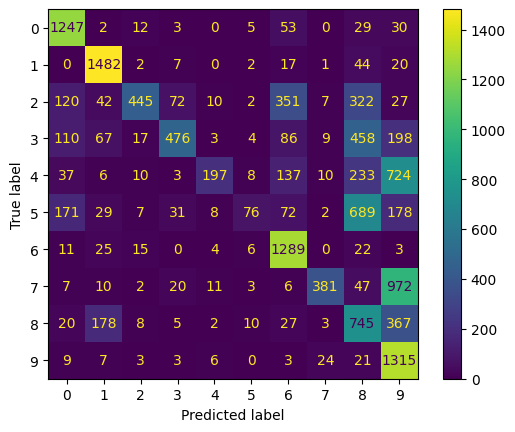

In [14]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=classes)
plt.show()

El análisis de la matriz de confusión revela que el modelo presenta dificultades para diferenciar los dígitos $8$ y $9$ de los números $2,3,4, 5$ y $7$. Este comportamiento no es esperarse: dada la alta variabilidad morfológica en la escritura y la simplicidad del modelo, las similitudes estructurales entre estos dígitos inducen errores de clasificación.


## 7. Generación de datos.

El proceso de generación de nuevas muestras consiste en realizar un muestreo aleatorio para cada píxel, utilizando las medias y varianzas estimadas durante el entrenamiento. Posteriormente, los vectores resultantes se reorganizan y grafican para visualizar la representación aprendida de cada dígito.


In [15]:
def show_generated_imgs(bayes, sample_size = 1):
  x_new = np.zeros((len(bayes.theta_), 784))

  for i in range(len(bayes.theta_)):
    mean = bayes.theta_[i, :]
    var = bayes.var_[i, :]

    sample = np.mean(np.random.normal(mean, np.sqrt(var), size=(sample_size, len(mean))), axis = 0)

    sample = np.clip(sample, 0, 255)
    x_new[i, :] = sample

  fig, ax = plt.subplots(2, 5, layout='tight', figsize=(10, 5))
  img_idx = 0
  for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
      ax[i, j].imshow(x_new[img_idx].reshape((28, 28)), cmap='gray')

      ax[i, j].set(title = f'Class: {img_idx}')
      ax[i, j].axis('off')

      img_idx += 1

  plt.suptitle(f'Imágenes resultantes con tamaño de muestra {sample_size}')

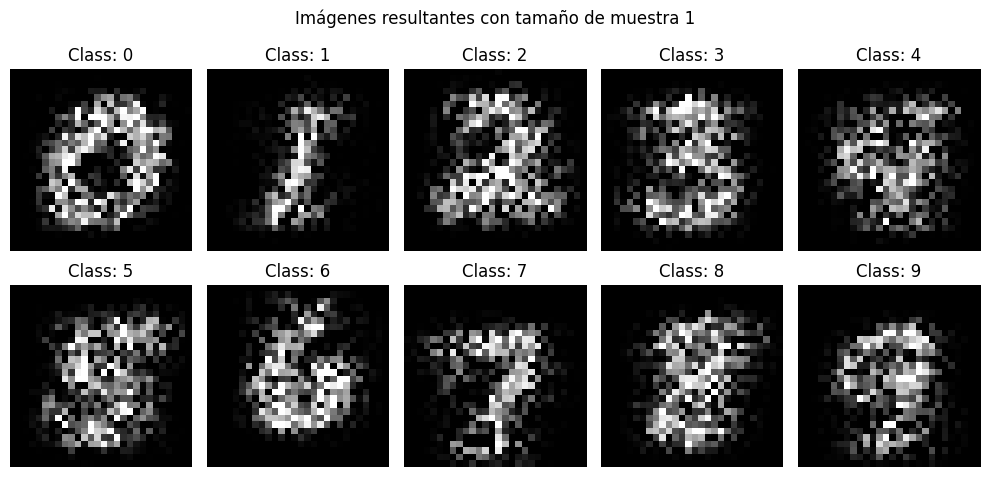

In [16]:
show_generated_imgs(bayes)

El resultado del muestreo estocástico genera imágenes con un ruido evidente, lo cual es de esperarse bajo la premisa de independencia condicional. Debido a que el valor de cada píxel no depende de los píxeles de su alrededor, se producen saltos bruscos de intensidad que rompen la continuidad del trazo. Sin embargo, es notable que, incluso con este ruido, el modelo es capaz de preservar la silueta y la estructura fundamental que define a cada dígito.


Para mitigar el ruido estocástico, se generaron $1000$ muestras por cada dígito y se calculó su valor esperado. El resultado revela formas mucho más nítidas y coherentes, lo que confirma que el modelo ha capturado con precisión la estructura subyacente de los datos. Cabe destacar que, matemáticamente, obtener el valor esperado de estas muestras converge a la media de cada píxel, por lo tanto, las imágenes resultantes representan el "dígito promedio" o el prototipo ideal aprendido por el modelo.


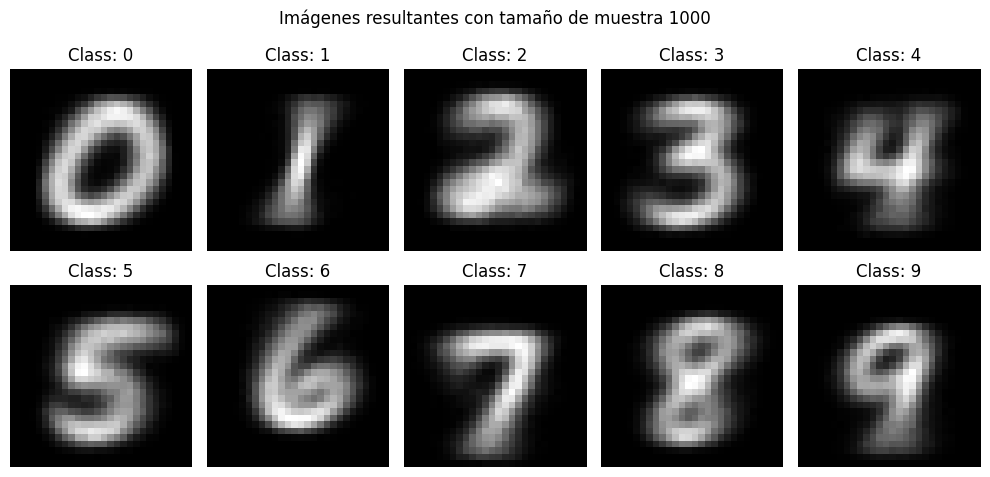

In [17]:
show_generated_imgs(bayes, sample_size=1000)

## 7. Ejercicios

+ **Ejercicio 1**. En el caso de trabajar con un conjunto de datos significativamente desbalanceado, ¿cómo se vería afectada la distribución $\mathbb{P}(Y)$? Explique de qué manera este desequilibrio impactaría en el desempeño y las predicciones del modelo. Finalmente, proponga qué medidas podrían implementarse para mitigar este efecto.

+ **Ejercicio 2**. Considerando la naturaleza de las distribuciones aprendidas por `GaussianNB()`, calcule de forma manual la media y la varianza de los datos en `x_train` para cada clase. Posteriormente, compare estos valores con los parámetros estimados por el modelo. ¿Qué conclusiones puede extraer de esta comparación?

+ **Ejercicio 3**. Seleccione una muestra aleatoria del conjunto de evaluación. A continuación, utilice la función `norm.pdf` del módulo `scipy.stats` para calcular las verosimilitudes y determinar la clase de dicha muestra aplicando las expresiones desarrolladas en la sección 6. *Evaluación del desempeño*. ¿Es el resultado obtenido consistente con la predicción que entrega el modelo para esta misma muestra?

+ **Ejercicio 4**. Tomando como referencia las imágenes de la sección 7. *Generación de datos*, genere un gráfico similar en el que ahora se visualice la varianza de cada clase. ¿Qué interpretación puede extraer de estos resultados? Específicamente, ¿qué información proporciona la intensidad de la varianza respecto a la distribución de los trazos en cada dígito?
